In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
df = pd.read_csv('D:\ML-assignment\data\kidney_disease.csv')

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (400, 26)


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [6]:
print("=== Data Types & Non-null Counts ===")
df.info()

print("\n=== Missing Values Per Column ===")
print(df.isnull().sum())

print("\n=== Target Column (raw) ===")
print(df['classification'].value_counts())

=== Data Types & Non-null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17

In [7]:
# Drop irrelevant columns
if 'id' in df.columns:
    df = df.drop(columns=['id'])
    print("'id' column dropped.")

# Define the 24 features used for prediction
selected_features = [
    'age', 'bp', 'sg', 'al', 'su',
    'rbc', 'pc', 'pcc', 'ba',
    'bgr', 'bu', 'sc', 'sod', 'pot',
    'hemo', 'pcv', 'wc', 'rc',
    'htn', 'dm', 'cad',
    'appet', 'pe', 'ane'
]

# Keep only selected features + target
df = df[selected_features + ['classification']]

print("Features selected :", len(selected_features))
print("Dataset shape after feature selection:", df.shape)
print("\nSelected columns:")
print(df.columns.tolist())

'id' column dropped.
Features selected : 24
Dataset shape after feature selection: (400, 25)

Selected columns:
['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']


In [8]:
# Remove hidden spaces from column names
df.columns = df.columns.str.strip()

# Replace '?' with proper NaN
df.replace('?', np.nan, inplace=True)

# Convert numeric columns that were read as text
numeric_cols = ['age','bp','sg','al','su','bgr','bu',
                'sc','sod','pot','hemo','pcv','wc','rc']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Data types after fix:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())

Data types after fix:
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                object
pc                 object
pcc                object
ba                 object
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv               float64
wc                float64
rc                float64
htn                object
dm                 object
cad                object
appet              object
pe                 object
ane                object
classification     object
dtype: object

Missing values per column:
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87


In [9]:
# Find all remaining text columns except target
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols = [c for c in categorical_cols if c != 'classification']

print("Columns to encode:", categorical_cols)

# Fill NaN in categorical columns before encoding
for col in categorical_cols:
    df[col] = df[col].fillna('missing')

# Label encode each column
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Encode target column
df['classification'] = df['classification'].astype(str).str.strip().str.lower()
df['classification'] = df['classification'].map({'ckd': 1, 'notckd': 0})

print("\nEncoding complete!")
print("Target value counts:", df['classification'].value_counts().to_dict())


Columns to encode: ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']

Encoding complete!
Target value counts: {1: 250, 0: 150}


In [10]:
X = df.drop('classification', axis=1)
y = df['classification']

print("X shape:", X.shape)
print("y shape:", y.shape)

# Impute for visualisation only
imputer_viz = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(
    imputer_viz.fit_transform(X),
    columns=X.columns
)

X_imputed = X_imputed.reset_index(drop=True)
y = y.reset_index(drop=True)

print("\nMissing values after imputation:", X_imputed.isnull().sum().sum())

X shape: (400, 24)
y shape: (400,)

Missing values after imputation: 0


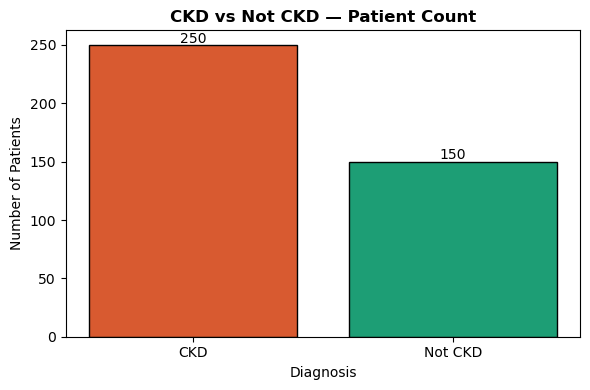

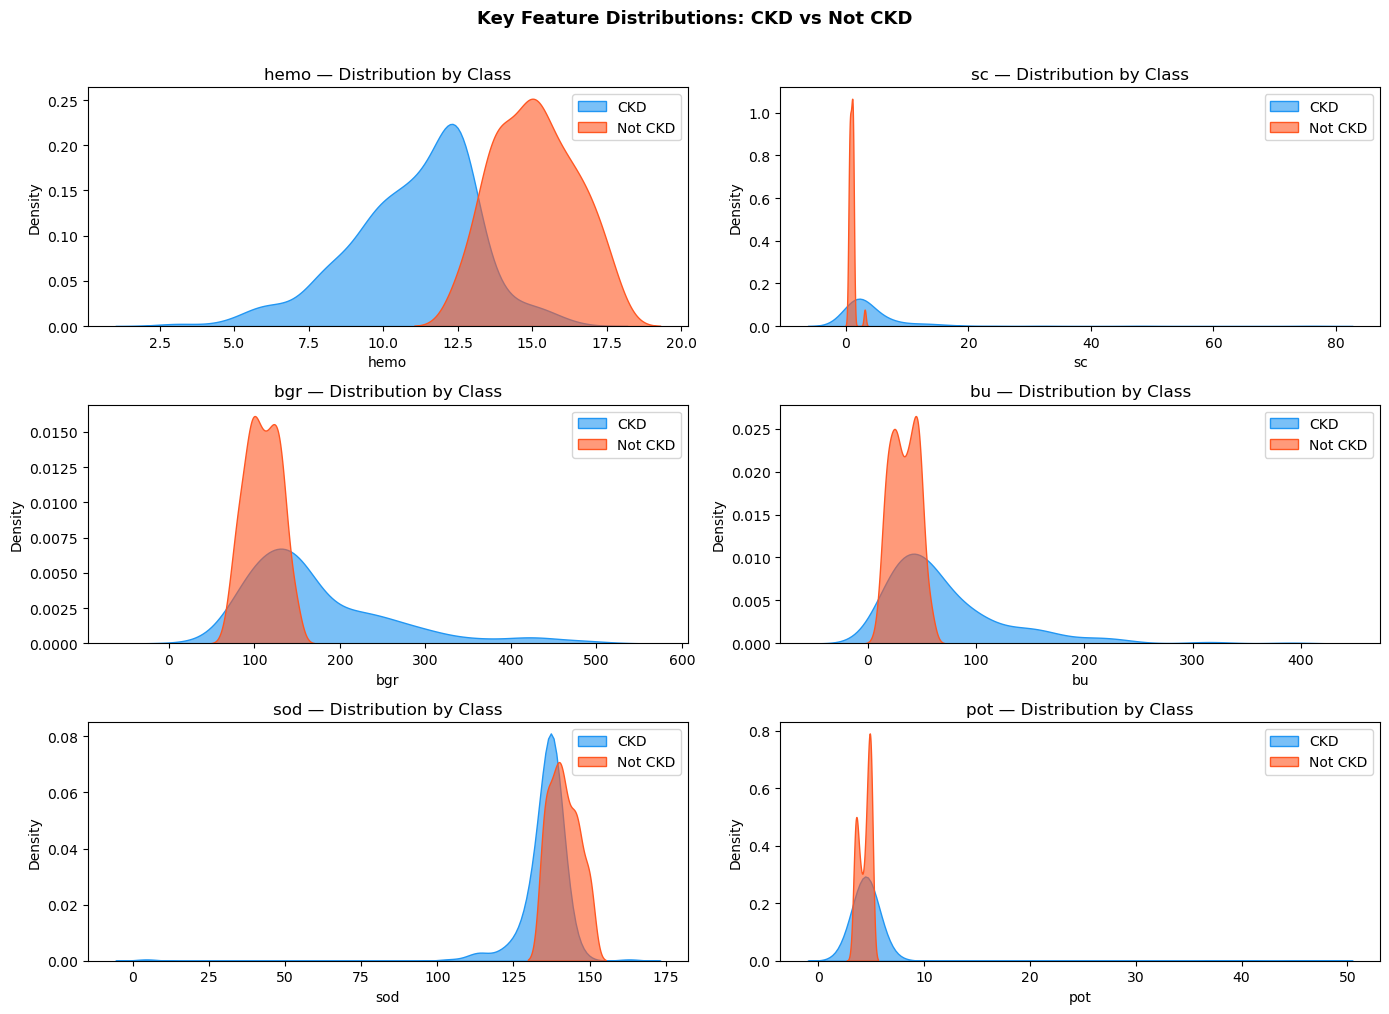

In [11]:
# --- Plot 1: CKD vs Not CKD Count ---
counts = y.value_counts()
labels = ['CKD' if i == 1 else 'Not CKD' for i in counts.index]

plt.figure(figsize=(6, 4))
ax = plt.bar(labels, counts.values,
             color=['#D85A30', '#1D9E75'], edgecolor='black')
plt.title('CKD vs Not CKD — Patient Count', fontsize=12, fontweight='bold')
plt.xlabel('Diagnosis', fontsize=10)
plt.ylabel('Number of Patients', fontsize=10)

for i, v in enumerate(counts.values):
    plt.text(i, v + 2, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# --- Plot 2: KDE Feature Distributions by Class ---
key_features = ['hemo', 'sc', 'bgr', 'bu', 'sod', 'pot']

plt.figure(figsize=(14, 10))

for i, feat in enumerate(key_features):
    plt.subplot(3, 2, i + 1)
    sns.kdeplot(X_imputed[feat][y == 1], label='CKD',
                fill=True, color='#2196F3', alpha=0.6)
    sns.kdeplot(X_imputed[feat][y == 0], label='Not CKD',
                fill=True, color='#FF5722', alpha=0.6)
    plt.title(f'{feat} — Distribution by Class')
    plt.legend()

plt.suptitle('Key Feature Distributions: CKD vs Not CKD',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [12]:
# Split FIRST — before imputing or scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Impute: fit on train only, apply to both
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test  = imputer.transform(X_test)

# Scale: fit on train only, apply to both
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print("Preprocessing pipeline complete!")

Training samples : 320
Testing samples  : 80
Preprocessing pipeline complete!


In [13]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, cv=cv)

print("Model training complete!")
print("\nCross-Validation Accuracy across 5 folds:")
for i, score in enumerate(cv_scores):
    print(f"  Fold {i+1}: {score*100:.2f}%")
print(f"\nMean CV Accuracy : {cv_scores.mean()*100:.2f}%")
print(f"Std Deviation    : {cv_scores.std()*100:.2f}%")

Model training complete!

Cross-Validation Accuracy across 5 folds:
  Fold 1: 100.00%
  Fold 2: 100.00%
  Fold 3: 100.00%
  Fold 4: 98.44%
  Fold 5: 100.00%

Mean CV Accuracy : 99.69%
Std Deviation    : 0.62%


In [14]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("First 10 predictions:   ", y_pred[:10])
print("First 10 actual labels: ", y_test.iloc[:10].values)

First 10 predictions:    [0 1 1 0 1 1 0 1 1 1]
First 10 actual labels:  [0 1 1 0 1 1 0 1 1 1]


In [15]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Not CKD', 'CKD']))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

Accuracy: 97.50%

Classification Report:
              precision    recall  f1-score   support

     Not CKD       0.94      1.00      0.97        30
         CKD       1.00      0.96      0.98        50

    accuracy                           0.97        80
   macro avg       0.97      0.98      0.97        80
weighted avg       0.98      0.97      0.98        80

ROC-AUC Score: 0.9993


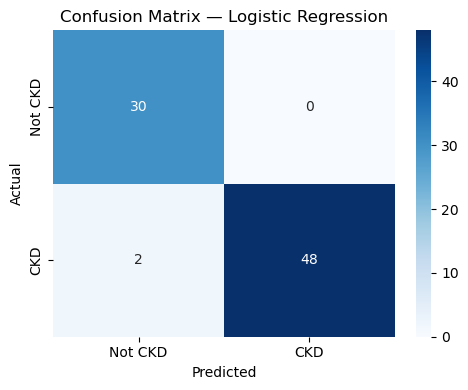

True Positives  (CKD correctly detected)   : 48
True Negatives  (Healthy correctly cleared) : 30
False Positives (Healthy wrongly flagged)   : 0
False Negatives (CKD missed by model)       : 2


In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not CKD', 'CKD'],
            yticklabels=['Not CKD', 'CKD'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives  (CKD correctly detected)   : {tp}")
print(f"True Negatives  (Healthy correctly cleared) : {tn}")
print(f"False Positives (Healthy wrongly flagged)   : {fp}")
print(f"False Negatives (CKD missed by model)       : {fn}")

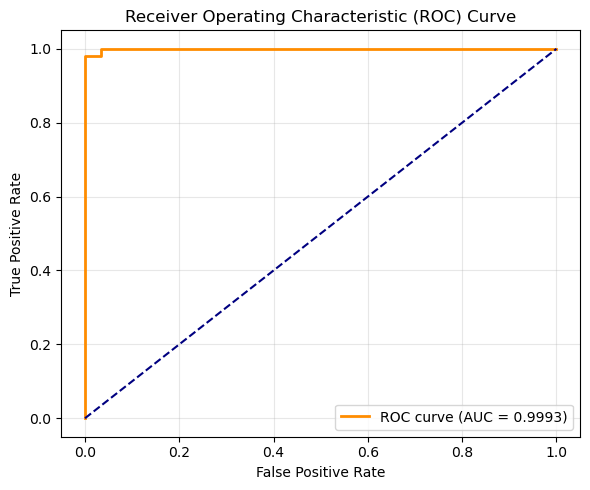

In [17]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Top 10 most important features:
Feature  Coefficient
    rbc    -1.614996
    pcv    -1.350276
   hemo    -1.245053
     sg    -1.223480
    htn     0.970427
    bgr     0.877748
     al     0.779802
     rc    -0.692702
  appet     0.616517
     sc     0.609330


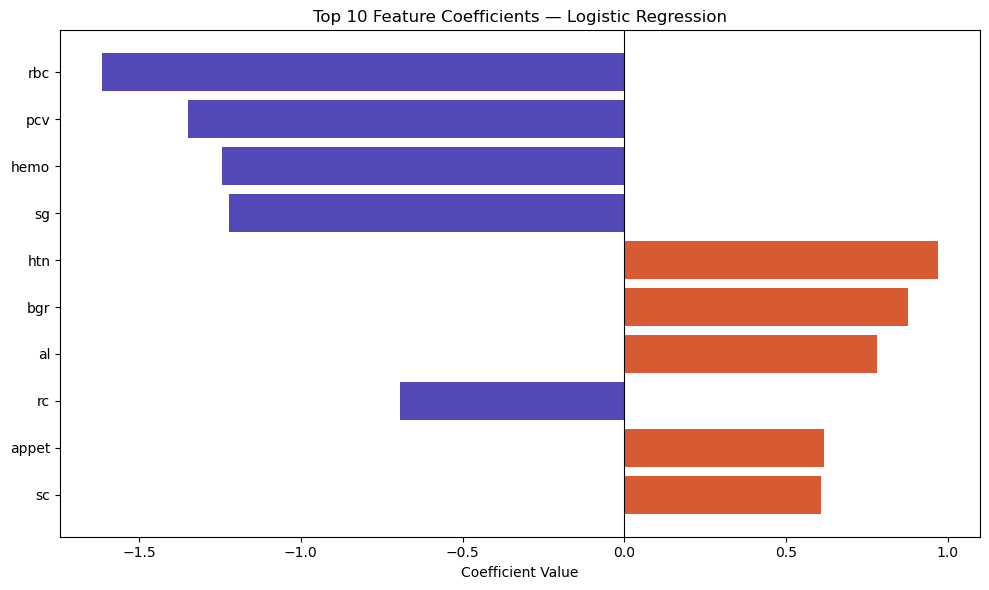


Positive risk factors (increase CKD risk):
Feature  Coefficient
    htn     0.970427
    bgr     0.877748
     al     0.779802
  appet     0.616517
     sc     0.609330

Protective factors (reduce CKD risk):
Feature  Coefficient
    rbc    -1.614996
    pcv    -1.350276
   hemo    -1.245053
     sg    -1.223480
     rc    -0.692702


In [18]:
feature_names = X.columns
coefficients  = model.coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs': np.abs(coefficients)
}).sort_values('Abs', ascending=False)

print("Top 10 most important features:")
print(coef_df[['Feature', 'Coefficient']].head(10).to_string(index=False))

top10  = coef_df.head(10)
colors = ['#D85A30' if x > 0 else '#534AB7' for x in top10['Coefficient']]

plt.figure(figsize=(10, 6))
plt.barh(top10['Feature'], top10['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 10 Feature Coefficients — Logistic Regression')
plt.xlabel('Coefficient Value')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nPositive risk factors (increase CKD risk):")
print(coef_df[coef_df['Coefficient'] > 0][['Feature','Coefficient']].head().to_string(index=False))

print("\nProtective factors (reduce CKD risk):")
print(coef_df[coef_df['Coefficient'] < 0][['Feature','Coefficient']].head().to_string(index=False))

In [19]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("=" * 50)
print("  LOGISTIC REGRESSION — RESULTS SUMMARY")
print("=" * 50)
print(f"  Dataset       : Chronic Kidney Disease")
print(f"  Total samples : {len(df)}")
print(f"  Train/Test    : 80% / 20%")
print(f"  Features used : {X_train.shape[1]}")
print("-" * 50)
print(f"  Accuracy      : {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"  ROC-AUC       : {roc_auc_score(y_test, y_prob):.4f}")
print("-" * 50)
print(f"  True Positives  (CKD correctly detected)   : {tp}")
print(f"  True Negatives  (Healthy correctly cleared) : {tn}")
print(f"  False Positives (Healthy wrongly flagged)   : {fp}")
print(f"  False Negatives (CKD missed)                : {fn}")
print("=" * 50)

  LOGISTIC REGRESSION — RESULTS SUMMARY
  Dataset       : Chronic Kidney Disease
  Total samples : 400
  Train/Test    : 80% / 20%
  Features used : 24
--------------------------------------------------
  Accuracy      : 97.50%
  ROC-AUC       : 0.9993
--------------------------------------------------
  True Positives  (CKD correctly detected)   : 48
  True Negatives  (Healthy correctly cleared) : 30
  False Positives (Healthy wrongly flagged)   : 0
  False Negatives (CKD missed)                : 2
